# IRI

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [15]:
import calendar

import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from src.constants import *

In [32]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
df_stats_iri = stratus.load_parquet_from_blob(blob_name)
df_stats_iri = df_stats_iri[df_stats_iri["year"] < 2025]

In [33]:
df_stats_iri

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,0.0,NaN
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,0.0,NaN
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,0.0,NaN
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,0.0,NaN
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,0.0,NaN
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,0.0,NaN
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,0.0,NaN


In [34]:
min_year, max_year = 1991, 2024
total_years = max_year - min_year + 1
rp_overall_target = 4
n_years_overall_target = int((max_year - min_year + 1 + 1) / rp_overall_target)

In [35]:
max_badyear_target = df_stats_iri.sort_values(
    "Humanitarian Bad Years (rank)"
).iloc[n_years_overall_target - 1]["Humanitarian Bad Years (rank)"]

In [36]:
df_stats_iri["target"] = (
    df_stats_iri["Humanitarian Bad Years (rank)"] <= max_badyear_target
)

In [37]:
df_stats_iri["target"].sum()

np.int64(9)

In [202]:
thresh_chirps = (
    df_stats_iri["CHIRPS Precip JAS (mm)"]
    .nsmallest(n_years_overall_target)
    .max()
)
df_stats_iri["target_chirps"] = (
    df_stats_iri["CHIRPS Precip JAS (mm)"] <= thresh_chirps
)

In [203]:
df_stats_iri["target_chirps"].sum()

np.int64(8)

<Axes: >

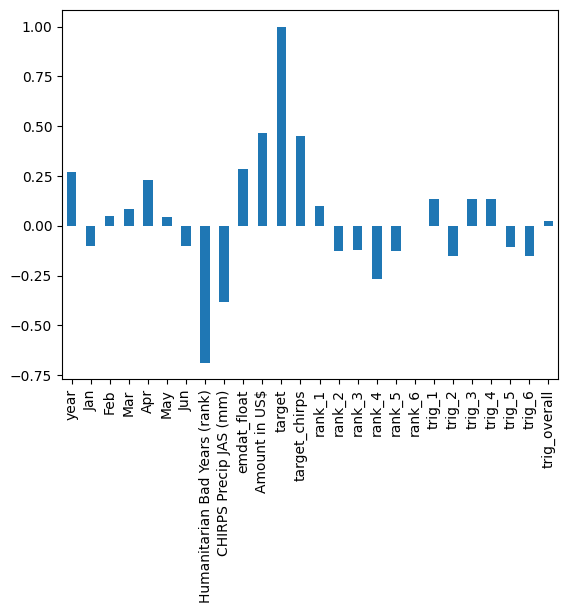

In [204]:
df_stats_iri.corr(numeric_only=True)["target"].plot.bar()

<Axes: >

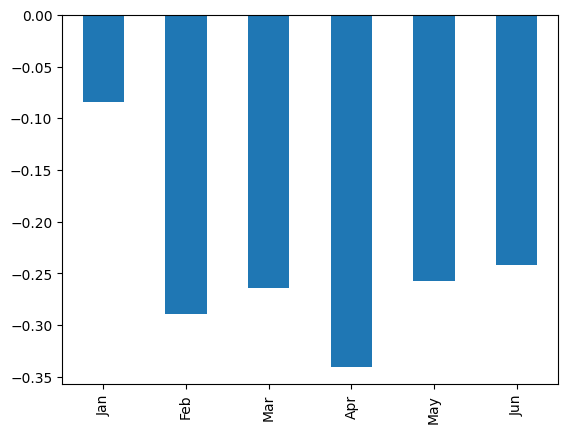

In [230]:
df_stats_iri.corr(numeric_only=True)["Humanitarian Bad Years (rank)"][
    [calendar.month_abbr[x] for x in range(1, 7)]
].plot.bar()

<Axes: title={'center': 'Corrélation avec CHIRPS'}>

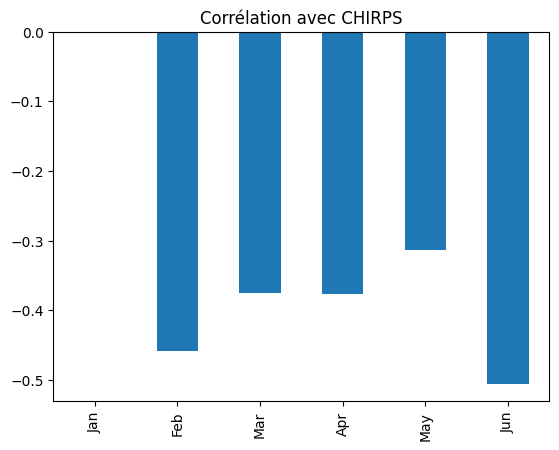

In [233]:
df_stats_iri.corr(numeric_only=True)["CHIRPS Precip JAS (mm)"][
    [calendar.month_abbr[x] for x in range(1, 7)]
].plot.bar(title="Corrélation avec CHIRPS")

<Axes: >

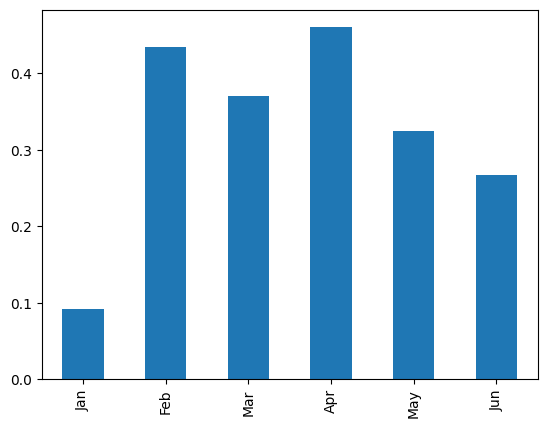

In [228]:
df_stats_iri.corr(numeric_only=True)["target_chirps"][
    [calendar.month_abbr[x] for x in range(1, 7)]
].plot.bar()

In [208]:
target_col = "target"

results = []

for target_col in ["target", "target_chirps"]:
    for mo in range(1, 7):
        auc = roc_auc_score(
            df_stats_iri[target_col], df_stats_iri[calendar.month_abbr[mo]]
        )
        results.append({"mo": mo, "roc_auc": auc, "target_col": target_col})


df_roc = pd.DataFrame(results)
df_roc

,mo,roc_auc,target_col
0,1,0.435556,target
1,2,0.582222,target
2,3,0.580000,target
3,4,0.673333,target
4,5,0.582222,target
5,6,0.502222,target
6,1,0.524038,target_chirps
7,2,0.798077,target_chirps
8,3,0.735577,target_chirps
9,4,0.841346,target_chirps


<Axes: xlabel='mo'>

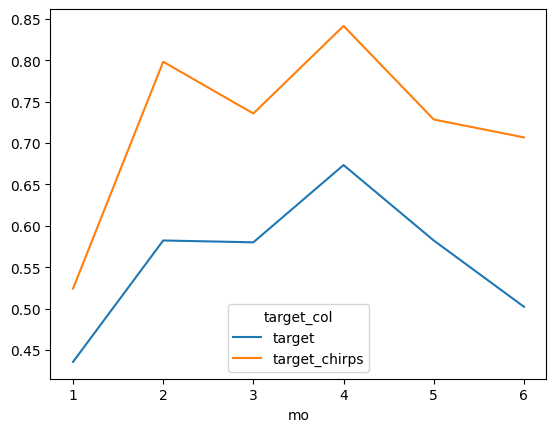

In [209]:
df_roc.pivot(index="mo", columns="target_col", values="roc_auc").plot()

In [210]:
for mo in range(1, 7):
    df_stats_iri[f"rank_{mo}"] = df_stats_iri[calendar.month_abbr[mo]].rank(
        ascending=False
    )

In [211]:
df_stats_iri

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),...,rank_4,rank_5,rank_6,trig_1,trig_2,trig_3,trig_4,trig_5,trig_6,trig_overall
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,...,16.0,19.0,2.0,False,False,False,False,False,True,True
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,...,2.0,2.5,4.0,False,True,False,True,False,False,True
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,...,8.0,5.0,1.0,False,False,False,False,False,True,True
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,...,4.0,1.0,5.0,False,False,False,False,True,False,True
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,...,20.0,17.0,25.0,False,False,False,False,False,False,False
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,...,3.0,15.0,9.0,True,False,False,False,False,False,False
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,...,21.0,7.0,3.0,False,False,True,False,False,False,True
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,...,29.0,18.0,22.0,False,False,False,False,False,False,False
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,...,7.0,25.0,26.5,False,False,False,False,False,False,False
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,...,22.0,9.5,20.0,False,False,False,False,False,False,False


In [212]:
trig_cols = [f"trig_{mo}" for mo in range(3, 7)]

dicts = []
for ind_trig_years in range(1, total_years):
    rp_ind = (total_years + 1) / ind_trig_years
    cols = []
    for mo in range(3, 7):
        df_stats_iri[f"trig_{mo}"] = (
            df_stats_iri[f"rank_{mo}"] <= ind_trig_years
        )
    df_stats_iri["trig_overall"] = df_stats_iri[trig_cols].any(axis=1)
    pp = df_stats_iri["trig_overall"]
    rp = (total_years + 1) / pp.sum()
    for target_col in ["target", "target_chirps"]:
        p = df_stats_iri[target_col]
        tp = p & pp
        tpr = tp.sum() / p.sum()
        ppv = tp.sum() / pp.sum()
        f1 = 2 * tpr * ppv / (tpr + ppv)

        dicts.append(
            {
                "rp": rp,
                "tpr": tpr,
                "ppv": ppv,
                "f1": f1,
                "target_col": target_col,
                "rp_ind": rp_ind,
                "ind_years": ind_trig_years,
            }
        )

df_metrics = pd.DataFrame(dicts)

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_46139/2139275175.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * tpr * ppv / (tpr + ppv)


[None, None]

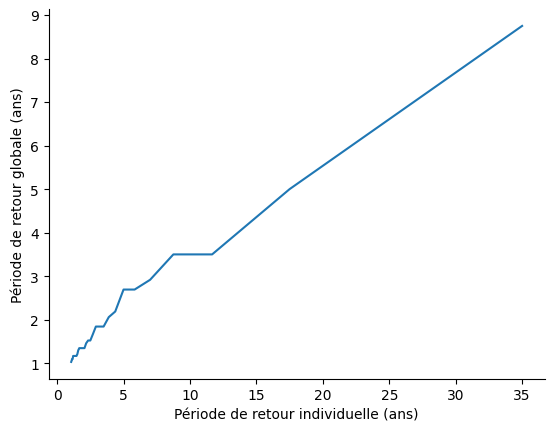

In [213]:
fig, ax = plt.subplots()
df_metrics[df_metrics["target_col"] == "target"].plot(
    x="rp_ind", y="rp", ax=ax, legend=False
)

ax.set_xlabel("Période de retour individuelle (ans)")
ax.set_ylabel("Période de retour globale (ans)")
[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [214]:
df_metrics[df_metrics["target_col"] == "target_chirps"]

,rp,tpr,ppv,f1,target_col,rp_ind,ind_years
1,8.750000,0.000,0.000000,NaN,target_chirps,35.000000,1
3,5.000000,0.375,0.428571,0.400000,target_chirps,17.500000,2
5,3.500000,0.625,0.500000,0.555556,target_chirps,11.666667,3
7,3.500000,0.625,0.500000,0.555556,target_chirps,8.750000,4
9,2.916667,0.750,0.500000,0.600000,target_chirps,7.000000,5
11,2.692308,0.750,0.461538,0.571429,target_chirps,5.833333,6
13,2.692308,0.750,0.461538,0.571429,target_chirps,5.000000,7
15,2.187500,0.875,0.437500,0.583333,target_chirps,4.375000,8
17,2.058824,0.875,0.411765,0.560000,target_chirps,3.888889,9
19,1.842105,1.000,0.421053,0.592593,target_chirps,3.500000,10


<Axes: xlabel='rp'>

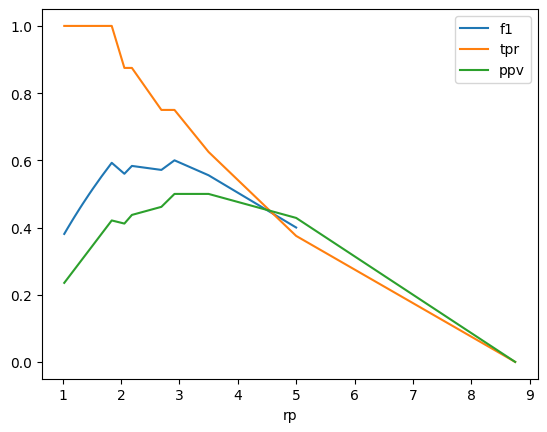

In [215]:
df_metrics[df_metrics["target_col"] == "target_chirps"].plot(
    x="rp", y=["f1", "tpr", "ppv"]
)

<Axes: xlabel='ind_years'>

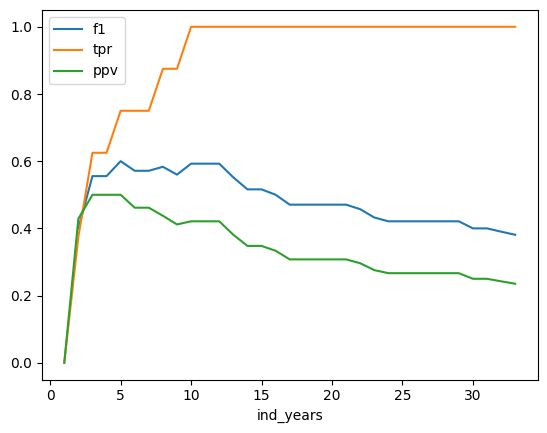

In [216]:
df_metrics[df_metrics["target_col"] == "target_chirps"].plot(
    x="ind_years", y=["f1", "tpr", "ppv"]
)

In [217]:
df_metrics[df_metrics["target_col"] == "target_chirps"]

,rp,tpr,ppv,f1,target_col,rp_ind,ind_years
1,8.750000,0.000,0.000000,NaN,target_chirps,35.000000,1
3,5.000000,0.375,0.428571,0.400000,target_chirps,17.500000,2
5,3.500000,0.625,0.500000,0.555556,target_chirps,11.666667,3
7,3.500000,0.625,0.500000,0.555556,target_chirps,8.750000,4
9,2.916667,0.750,0.500000,0.600000,target_chirps,7.000000,5
11,2.692308,0.750,0.461538,0.571429,target_chirps,5.833333,6
13,2.692308,0.750,0.461538,0.571429,target_chirps,5.000000,7
15,2.187500,0.875,0.437500,0.583333,target_chirps,4.375000,8
17,2.058824,0.875,0.411765,0.560000,target_chirps,3.888889,9
19,1.842105,1.000,0.421053,0.592593,target_chirps,3.500000,10


In [218]:
df_metrics[df_metrics["target_col"] == "target_chirps"]

,rp,tpr,ppv,f1,target_col,rp_ind,ind_years
1,8.750000,0.000,0.000000,NaN,target_chirps,35.000000,1
3,5.000000,0.375,0.428571,0.400000,target_chirps,17.500000,2
5,3.500000,0.625,0.500000,0.555556,target_chirps,11.666667,3
7,3.500000,0.625,0.500000,0.555556,target_chirps,8.750000,4
9,2.916667,0.750,0.500000,0.600000,target_chirps,7.000000,5
11,2.692308,0.750,0.461538,0.571429,target_chirps,5.833333,6
13,2.692308,0.750,0.461538,0.571429,target_chirps,5.000000,7
15,2.187500,0.875,0.437500,0.583333,target_chirps,4.375000,8
17,2.058824,0.875,0.411765,0.560000,target_chirps,3.888889,9
19,1.842105,1.000,0.421053,0.592593,target_chirps,3.500000,10


In [219]:
ind_trig_years = 2

rp_ind = (total_years + 1) / ind_trig_years
cols = []
for mo in range(1, 7):
    df_stats_iri[f"trig_{mo}"] = df_stats_iri[f"rank_{mo}"] <= ind_trig_years
df_stats_iri["trig_overall"] = df_stats_iri[trig_cols].any(axis=1)

<Axes: xlabel='year'>

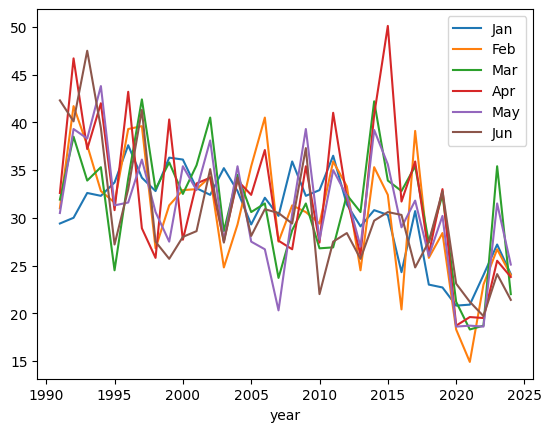

In [220]:
df_stats_iri.plot(x="year", y=[calendar.month_abbr[x] for x in range(1, 7)])

In [221]:
df_stats_iri["trig_overall"].sum()

np.int64(7)

In [222]:
df_stats_iri.columns

Index(['year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
       'Humanitarian Bad Years (rank)', 'EM-DAT Bad Years',
       'CHIRPS Precip JAS (mm)', 'emdat_float', 'Amount in US$', 'target',
       'target_chirps', 'rank_1', 'rank_2', 'rank_3', 'rank_4', 'rank_5',
       'rank_6', 'trig_1', 'trig_2', 'trig_3', 'trig_4', 'trig_5', 'trig_6',
       'trig_overall'],
      dtype='object')

In [224]:
def highlight_triggered(row):
    styles = [""] * len(row)

    col_map = {
        "Mar": "trig_3",
        "Apr": "trig_4",
        "May": "trig_5",
        "Jun": "trig_6",
        "CHIRPS Precip JAS (mm)": "target_chirps",
    }

    for i, col in enumerate(row.index):
        if col in col_map and row.get(col_map[col], False):
            styles[i] = "background-color: crimson"
    return styles


cols = (
    [calendar.month_abbr[x] for x in range(3, 7)]
    + ["CHIRPS Precip JAS (mm)"]
    + [f"trig_{x}" for x in range(3, 7)]
    + ["target_chirps"]
)

df_stats_iri.sort_values("year", ascending=False).set_index("year")[
    cols
].style.apply(highlight_triggered, axis=1).format("{:.1f}")

,Mar,Apr,May,Jun,CHIRPS Precip JAS (mm),trig_3,trig_4,trig_5,trig_6,target_chirps
year,,,,,,,,,,
2024,22.0,23.8,25.1,21.4,97.5,0.0,0.0,0.0,0.0,0.0
2023,35.4,25.5,31.5,24.1,81.0,0.0,0.0,0.0,0.0,0.0
2022,18.7,19.5,18.6,19.7,85.2,0.0,0.0,0.0,0.0,0.0
2021,18.3,19.6,18.7,21.2,70.0,0.0,0.0,0.0,0.0,0.0
2020,21.2,18.7,18.6,23.1,89.7,0.0,0.0,0.0,0.0,0.0
2019,32.4,33.0,30.2,32.8,63.3,0.0,0.0,0.0,0.0,1.0
2018,27.4,26.2,26.0,27.5,82.5,0.0,0.0,0.0,0.0,0.0
2017,35.4,35.9,31.8,24.8,64.7,0.0,0.0,0.0,0.0,1.0
2016,32.8,31.7,29.0,30.3,83.3,0.0,0.0,0.0,0.0,0.0


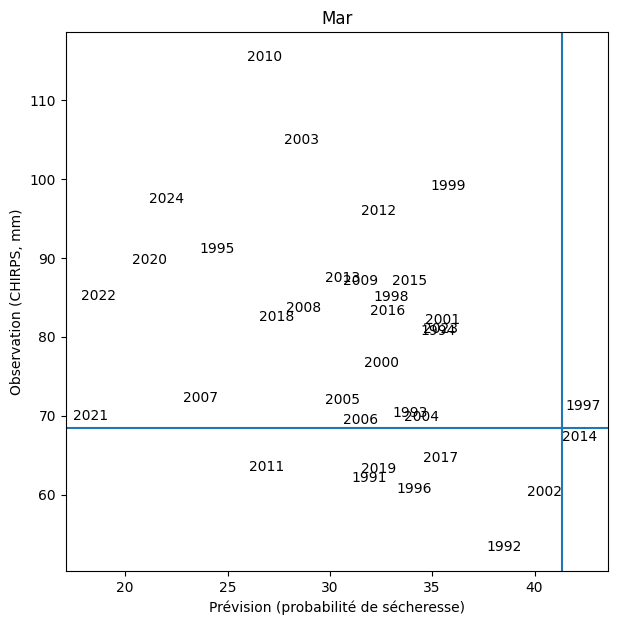

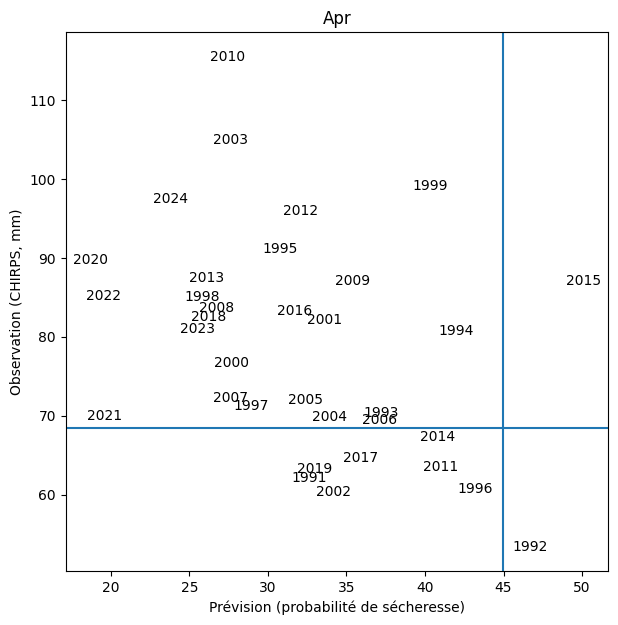

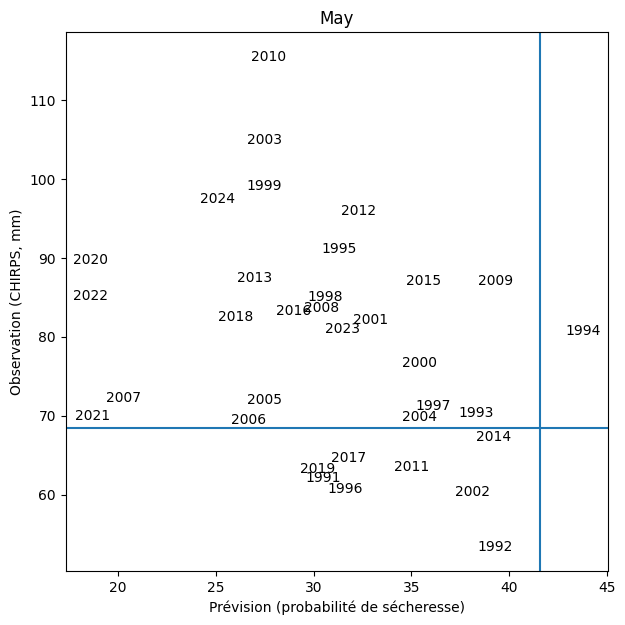

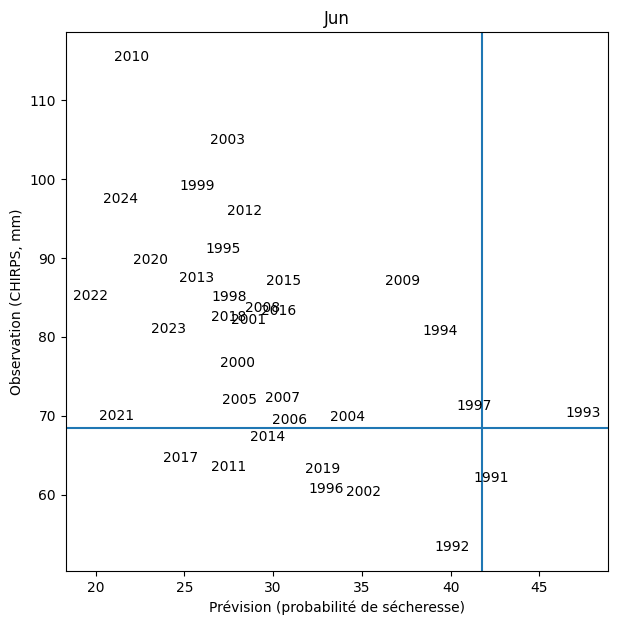

In [255]:
thresh_chirps = (
    df_stats_iri[df_stats_iri["target_chirps"]]["CHIRPS Precip JAS (mm)"].max()
    + df_stats_iri[~df_stats_iri["target_chirps"]][
        "CHIRPS Precip JAS (mm)"
    ].min()
) / 2

for mo in range(3, 7):
    col = calendar.month_abbr[mo]
    fig, ax = plt.subplots(figsize=(7, 7))
    df_stats_iri.plot(
        x=col,
        y="CHIRPS Precip JAS (mm)",
        ax=ax,
        linewidth=0,
        # marker=".",
        legend=False,
    )
    for _, row in df_stats_iri.iterrows():
        ax.annotate(
            row["year"],
            row[[col, "CHIRPS Precip JAS (mm)"]],
            va="center",
            ha="center",
        )
    thresh = (
        df_stats_iri[df_stats_iri[f"trig_{mo}"]][col].min()
        + df_stats_iri[~df_stats_iri[f"trig_{mo}"]][col].max()
    ) / 2
    ax.axhline(thresh_chirps)
    ax.axvline(thresh)
    ax.set_title(col)
    ax.set_xlabel("Prévision (probabilité de sécheresse)")
    ax.set_ylabel("Observation (CHIRPS, mm)")